🌐 Starting Web Scraping Process...
✅ Successfully scraped Page 1
✅ Successfully scraped Page 2
✅ Successfully scraped Page 3

📁 Bonus Complete: Scraped dataset exported to 'scraped_books_data_task5.csv'


/tmp/ipykernel_781/1338779146.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_books, x='Rating_Stars', y='Price_GBP', palette='Blues', ax=axes[0])
/tmp/ipykernel_781/1338779146.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_books, x='Rating_Stars', palette='viridis', ax=axes[1])
/tmp/ipykernel_781/1338779146.py:74: UserWarning: Glyph 128218 (\N{BOOKS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128218 (\N{BOOKS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


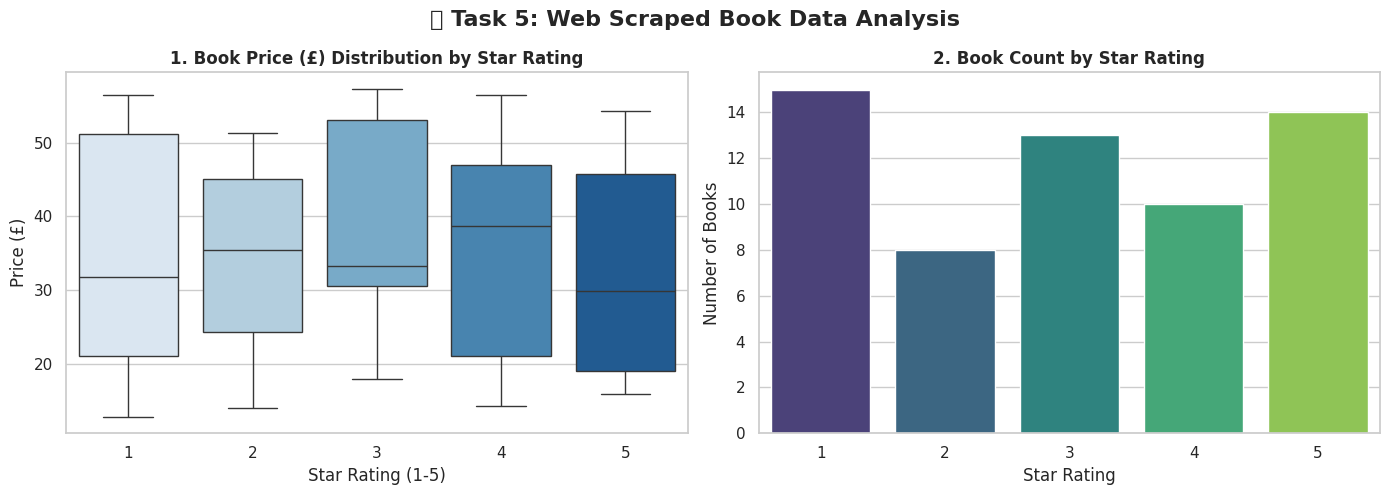


📊 DATASET SUMMARY METRICS:
Total Books Extracted: 60
Average Book Price: £35.00
Average Star Rating: 3.00 / 5


In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set aesthetic styling
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10})

# 1. Scrape Web Data (Books to Scrape Sandbox)
BASE_URL = "http://books.toscrape.com/catalogue/page-{}.html"
books_data = []

print("🌐 Starting Web Scraping Process...")

# Scrape first 3 pages
for page in range(1, 4):
    url = BASE_URL.format(page)
    response = requests.get(url)

    if response.status_code == 200:
        soup = BeautifulSoup(response.text, 'html.parser')
        articles = soup.find_all('article', class_='product_pod')

        for article in articles:
            # Title
            title = article.h3.a['title']

            # Price
            price_text = article.find('p', class_='price_color').text
            price = float(price_text.replace('£', '').replace('Â', ''))

            # Star Rating
            rating_class = article.find('p', class_='star-rating')['class'][1]
            rating_map = {'One': 1, 'Two': 2, 'Three': 3, 'Four': 4, 'Five': 5}
            rating = rating_map.get(rating_class, 0)

            # Availability
            availability = article.find('p', class_='instock availability').text.strip()

            books_data.append({
                'Title': title,
                'Price_GBP': price,
                'Rating_Stars': rating,
                'In_Stock': 'In stock' in availability
            })
        print(f"✅ Successfully scraped Page {page}")

# 2. Convert & Clean Data
df_books = pd.DataFrame(books_data)

# ⭐ Bonus: Automated CSV Export
csv_filename = 'scraped_books_data_task5.csv'
df_books.to_csv(csv_filename, index=False)
print(f"\n📁 Bonus Complete: Scraped dataset exported to '{csv_filename}'")

# 3. Exploratory Data Analysis & Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('📚 Task 5: Web Scraped Book Data Analysis', fontsize=16, fontweight='bold')

# Chart 1: Price Distribution by Rating
sns.boxplot(data=df_books, x='Rating_Stars', y='Price_GBP', palette='Blues', ax=axes[0])
axes[0].set_title('1. Book Price (£) Distribution by Star Rating', fontweight='bold')
axes[0].set_xlabel('Star Rating (1-5)')
axes[0].set_ylabel('Price (£)')

# Chart 2: Count of Books per Rating
sns.countplot(data=df_books, x='Rating_Stars', palette='viridis', ax=axes[1])
axes[1].set_title('2. Book Count by Star Rating', fontweight='bold')
axes[1].set_xlabel('Star Rating')
axes[1].set_ylabel('Number of Books')

plt.tight_layout()
plt.show()

# Print Summary Stats
print("\n📊 DATASET SUMMARY METRICS:")
print(f"Total Books Extracted: {len(df_books)}")
print(f"Average Book Price: £{df_books['Price_GBP'].mean():.2f}")
print(f"Average Star Rating: {df_books['Rating_Stars'].mean():.2f} / 5")